In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.experimental import enable_halving_search_cv  # necesario para Hyperband
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("dataset_limpio.csv")

X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [4]:
%%time

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Hyperband usando n_samples como recurso
hyperband = HalvingGridSearchCV(
    rf,
    param_grid,
    factor=3,
    resource="n_samples",   # ← CORRECCIÓN
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

hyperband.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(hyperband.best_params_)


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 305
max_resources_: 24724
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 108
n_resources: 305
Fitting 5 folds for each of 108 candidates, totalling 540 fits
----------
iter: 1
n_candidates: 36
n_resources: 915
Fitting 5 folds for each of 36 candidates, totalling 180 fits
----------
iter: 2
n_candidates: 12
n_resources: 2745
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 3
n_candidates: 4
n_resources: 8235
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 4
n_candidates: 2
n_resources: 24705
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
CPU times: user 12.9 s, sys: 457 ms, total: 13.4 s
Wall time: 2min 29s


In [5]:
y_pred = hyperband.predict(X_test)

print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

    electron       0.00      0.00      0.00        29
        muon       0.00      0.00      0.00        80
      photon       1.00      1.00      1.00        50
       track       0.98      1.00      0.99      6022

    accuracy                           0.98      6181
   macro avg       0.50      0.50      0.50      6181
weighted avg       0.97      0.98      0.97      6181



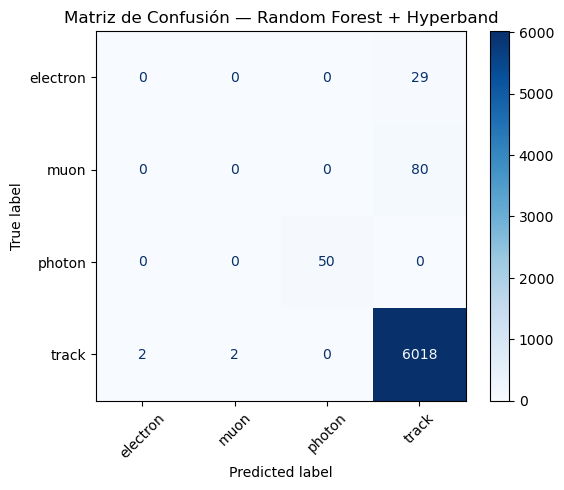

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — Random Forest + Hyperband")
plt.show()


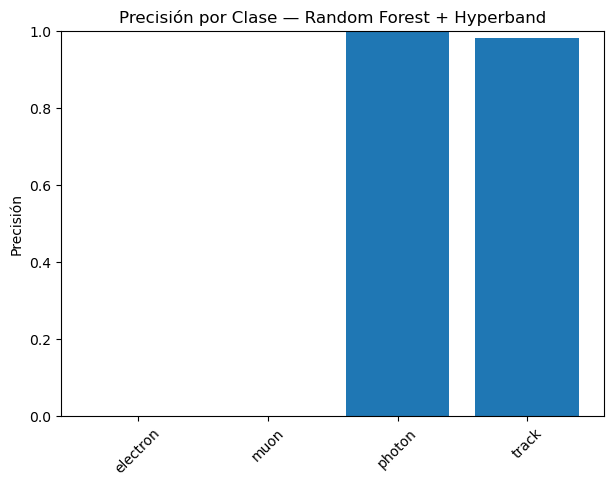

In [7]:
report = classification_report(
    y_test, y_pred, target_names=classes, output_dict=True
)

precisiones = [report[c]["precision"] for c in classes]

plt.figure(figsize=(7,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por Clase — Random Forest + Hyperband")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


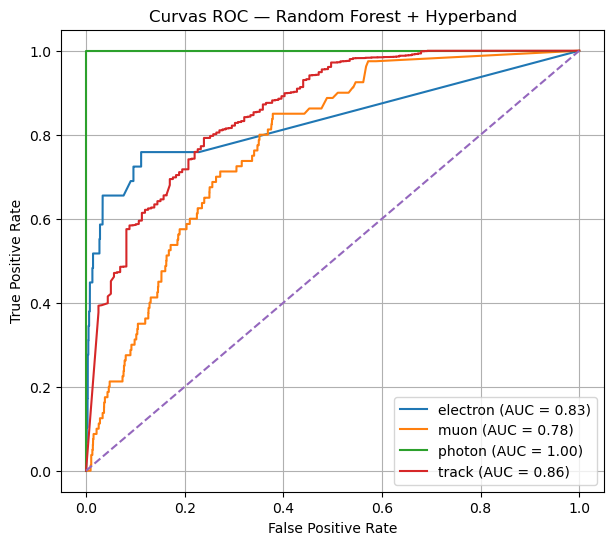

In [8]:
# One-hot encoding para Multiclase ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_score = hyperband.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — Random Forest + Hyperband")
plt.legend()
plt.grid()
plt.show()


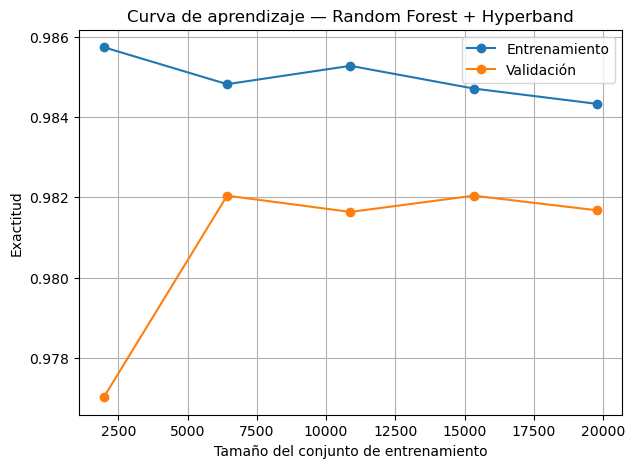

In [9]:
train_sizes, train_scores, test_scores = learning_curve(
    hyperband.best_estimator_,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — Random Forest + Hyperband")
plt.legend()
plt.grid()
plt.show()


## SIN TRACKS

In [10]:
df = pd.read_csv("dataset_limpio_notracks.csv")

X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [11]:
%%time

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Hyperband usando n_samples como recurso
hyperband = HalvingGridSearchCV(
    rf,
    param_grid,
    factor=3,
    resource="n_samples",   # ← CORRECCIÓN
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

hyperband.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(hyperband.best_params_)


n_iterations: 3
n_required_iterations: 5
n_possible_iterations: 3
min_resources_: 30
max_resources_: 635
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 108
n_resources: 30
Fitting 5 folds for each of 108 candidates, totalling 540 fits
----------
iter: 1
n_candidates: 36
n_resources: 90
Fitting 5 folds for each of 36 candidates, totalling 180 fits
----------
iter: 2
n_candidates: 12
n_resources: 270
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros encontrados:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
CPU times: user 2.44 s, sys: 86.8 ms, total: 2.52 s
Wall time: 1min 21s


In [12]:
y_pred = hyperband.predict(X_test)

print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

    electron       0.75      0.41      0.53        29
        muon       0.82      0.95      0.88        80
      photon       1.00      1.00      1.00        50

    accuracy                           0.87       159
   macro avg       0.86      0.79      0.80       159
weighted avg       0.86      0.87      0.85       159



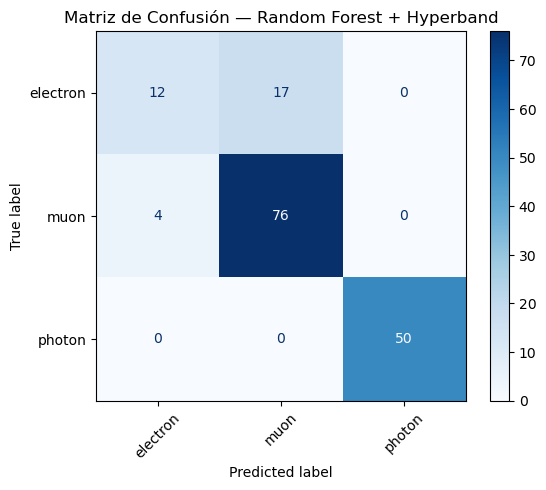

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — Random Forest + Hyperband")
plt.show()


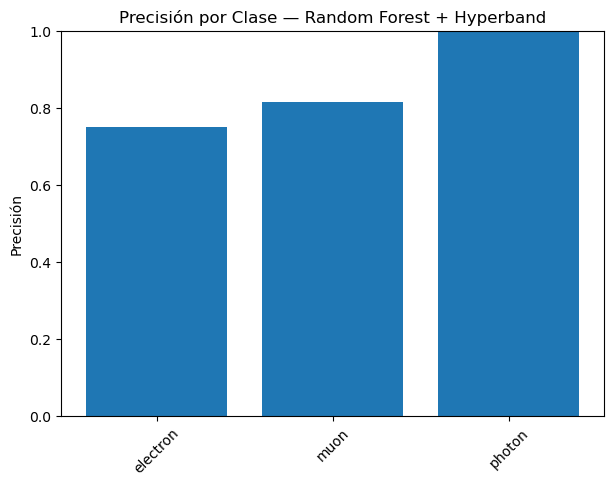

In [14]:
report = classification_report(
    y_test, y_pred, target_names=classes, output_dict=True
)

precisiones = [report[c]["precision"] for c in classes]

plt.figure(figsize=(7,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por Clase — Random Forest + Hyperband")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()



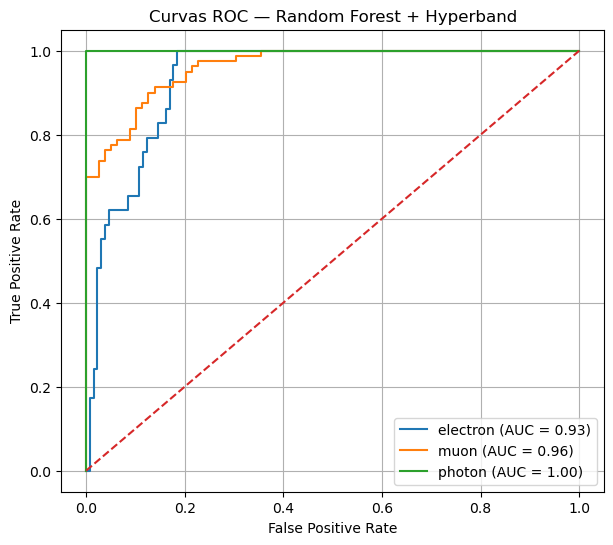

In [15]:
# One-hot encoding para Multiclase ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_score = hyperband.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — Random Forest + Hyperband")
plt.legend()
plt.grid()
plt.show()


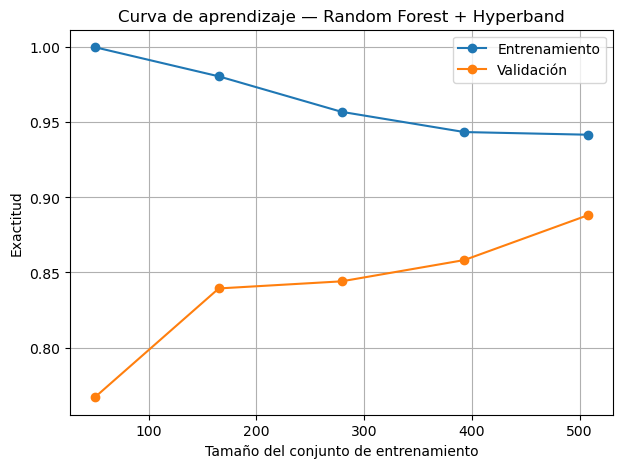

In [16]:
train_sizes, train_scores, test_scores = learning_curve(
    hyperband.best_estimator_,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — Random Forest + Hyperband")
plt.legend()
plt.grid()
plt.show()
